# COBRE fMRI Analysis — Louvain Community Structure & Schizophrenia Dysconnectivity

## Pipeline Overview

This notebook implements the full analysis pipeline on the GLasso connectomes computed from the COBRE dataset.
The scientific question is: **do schizophrenia patients show abnormal brain network organisation compared to healthy controls, and which specific inter-regional connections are responsible?**

The pipeline follows these stages:

1. Load the HC and SCZ precision matrices from the HDF5 database
2. Compute a **HC consensus partition** (the 'healthy reference') from the mean HC matrix
3. Run Louvain on each **individual SCZ subject** and compare their partition to the HC reference
4. Identify **spurious inter-community edges** (bridges that should not exist in healthy brains)
5. **Simulate healing** by progressively removing the most pathological edges and measuring Q recovery
6. **Visualise** everything: Q distributions, recovery curves, 3D brain maps, and bridge node maps

---
## Cell 1 — Imports and Configuration

We gather all dependencies upfront so the rest of the notebook is clean.

**Key choices:**
- `sklearn.metrics` for ARI / NMI — standard partition comparison metrics
- `scipy.stats` for Mann-Whitney U test — preferred over t-test here because Q scores are not guaranteed to be normally distributed, and our sample sizes (70 HC, 68 SCZ) are modest
- `nilearn.plotting` for 3D brain maps — the atlas objects already carry MNI coordinates so this is the natural choice
- `matplotlib` + `seaborn` for statistical charts — seaborn violin plots handle small samples more honestly than bar charts

In [ ]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import warnings
from collections import defaultdict

# ── Numerical / data ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import h5py

# ── Graph ─────────────────────────────────────────────────────────────────────
import networkx as nx
from tqdm.notebook import tqdm


# ── Statistics ────────────────────────────────────────────────────────────────
from scipy.stats import mannwhitneyu
# ARI (Adjusted Rand Index): measures overlap between two partitions corrected for chance.
# NMI (Normalized Mutual Information): information-theoretic overlap, insensitive to community count.
# We compute both because ARI penalises splits/merges more harshly than NMI.
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# ── Brain atlas & visualisation ───────────────────────────────────────────────
import nibabel as nib
from nilearn import datasets, plotting, image
from nilearn.maskers import NiftiLabelsMasker

# ── Plotting ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')   # suppress nilearn cache / deprecation noise


from pathlib import Path
import os

def find_project_root(marker='README.md'):
    """
    Walk upward from the current working directory until we find a folder
    containing the marker file. This works regardless of where Jupyter
    or VS Code was launched from, and works identically on every team
    member's machine.
    """
    path = Path(os.getcwd())
    for candidate in [path, *path.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(
        f'Could not find project root. Looked for {marker} starting from {path}.\n'
        f'Make sure README.md exists at the project root.'
    )

PROJECT_ROOT = find_project_root()
DB_PATH      = PROJECT_ROOT / 'SMA_data_processing' / 'cobre_combined_connectomes_database.h5'

print(f'Project root : {PROJECT_ROOT}')
print(f'DB path      : {DB_PATH}')
print(f'File exists  : {DB_PATH.exists()}')
# ── Global configuration ──────────────────────────────────────────────────────
#DB_PATH     = './SMA_data_processing/cobre_connectomes_database.h5'
GAMMA       = 1.0      # Louvain resolution — 1.0 is standard, see Cell 3 for discussion
THRESHOLD   = 1e-3     # modularity convergence threshold (matches louvain.ipynb)
MAX_LEVELS  = 1000     # maximum Louvain levels
RANDOM_SEED = 42       # for reproducibility wherever randomness is involved
print(os.path.abspath("./SMA_data_processing/cobre_combined_connectomes_database.h5"))
print(os.getcwd())

# Colour palette — consistent across all figures
PALETTE = {'HC': '#4C9BE8', 'SCZ': '#E8734C'}

print('All imports successful.')

Project root : c:\Users\anabo\Documents\Master\SP26\Social Media Analytics\project
DB path      : c:\Users\anabo\Documents\Master\SP26\Social Media Analytics\project\SMA_data_processing\cobre_combined_connectomes_database.h5
File exists  : True
c:\Users\anabo\Documents\Master\SP26\Social Media Analytics\project\SMA_data_processing\cobre_combined_connectomes_database.h5
c:\Users\anabo\Documents\Master\SP26\Social Media Analytics\project
All imports successful.


---
## Cell 2 — Paste the Louvain functions from louvain.ipynb

We reuse the exact functions validated in the previous notebook without modification.
They are reproduced here so this notebook is self-contained.

**Reminder of what each does:**
- `initial_assignment_communities` — trivial partition: every node is its own community
- `delta_q` — computes modularity gain for moving one node into a candidate community
- `louvain_step_one` — local optimisation phase (iterate until no node moves)
- `louvain_step_two` — graph coarsening: collapse communities into super-nodes
- `modularity` — computes the standard Newman-Girvan Q score
- `louvain` — runs the full two-phase loop until convergence

In [3]:
def initial_assignment_communities(G):
    return {node: node for node in G.nodes()}


def delta_q(G, node, target_community, communities, gamma=1.0, weight='weight'):
    degrees  = dict(G.degree(weight=weight))
    two_m    = sum(degrees.values())
    k_i_in   = sum(
        edge_data.get(weight, 0)
        for neighbor, edge_data in G[node].items()
        if neighbor != node and communities[neighbor] == target_community
    )
    k_i      = degrees[node]
    sigma_tot = sum(
        degrees[n]
        for n in G.nodes()
        if n != node and communities[n] == target_community
    )
    return (k_i_in / two_m) - gamma * (sigma_tot * k_i) / (two_m ** 2)


def louvain_step_one(G, gamma=1.0, weight='weight'):
    communities = initial_assignment_communities(G)
    moved = True
    while moved:
        moved = False
        for node in G.nodes():
            current_community = communities[node]
            communities[node] = -1
            target_communities = {
                communities[nb]
                for nb in G.neighbors(node)
                if communities[nb] != -1
            }
            best_community, best_dq = current_community, 0.0
            for tc in target_communities:
                dq = delta_q(G, node, tc, communities, gamma=gamma, weight=weight)
                if dq > best_dq:
                    best_dq, best_community = dq, tc
            communities[node] = best_community
            if best_community != current_community:
                moved = True
    return communities


def louvain_step_two(G, communities, weight='weight'):
    new_G = nx.Graph()
    for uc in set(communities.values()):
        new_G.add_node(uc)
    for n1, n2, edge_data in G.edges(data=True):
        c1, c2 = communities[n1], communities[n2]
        w = edge_data.get(weight, 0)
        if new_G.has_edge(c1, c2):
            new_G[c1][c2][weight] += w
        else:
            new_G.add_edge(c1, c2, **{weight: w})
    return new_G


def modularity(G, communities, weight='weight'):
    degrees = dict(G.degree(weight=weight))
    two_m   = sum(degrees.values())
    sigma   = 0.0
    nodes   = list(G.nodes())
    for i in nodes:
        for j in nodes:
            if communities[i] == communities[j]:
                A_ij   = G[i][j].get(weight, 0) if G.has_edge(i, j) else 0
                sigma += A_ij - (degrees[i] * degrees[j]) / two_m
    return sigma / two_m


def louvain(G, weight='weight', threshold=1e-3, max_levels=1000, gamma=1.0):
    """
    Full Louvain algorithm.
    Returns a dict {original_node: community_id} after convergence.
    """
    current_G = G
    levels    = 0
    communities_original = {node: node for node in G.nodes()}
    prev_modularity      = -1

    while levels < max_levels:
        communities     = louvain_step_one(current_G, gamma)
        curr_modularity = modularity(current_G, communities, weight=weight)

        if prev_modularity != -1 and abs(curr_modularity - prev_modularity) < threshold:
            break

        prev_modularity = curr_modularity

        new_G = louvain_step_two(current_G, communities, weight=weight)

        # Track the full path back to original node labels
        communities_original = {
            orig: communities[old_comm]
            for orig, old_comm in communities_original.items()
        }
        current_G = new_G
        levels   += 1

    return communities_original


# ── Helper: dict → list-of-sets (format expected by nx.modularity) ──────────
def communities_to_sets(communities_dict):
    grouped = defaultdict(set)
    for node, cid in communities_dict.items():
        grouped[cid].add(node)
    return list(grouped.values())


# ── Helper: dict → flat label array (format expected by sklearn metrics) ────
def communities_to_labels(communities_dict):
    """
    Returns a numpy array where index = node (assumes nodes are 0..N-1)
    and value = community id remapped to 0..K-1.
    """
    nodes = sorted(communities_dict.keys())
    raw   = np.array([communities_dict[n] for n in nodes])
    # remap community ids to contiguous integers
    unique = {v: i for i, v in enumerate(sorted(set(raw)))}
    return np.array([unique[v] for v in raw])


print('Louvain functions loaded.')

Louvain functions loaded.


In [4]:
# ── LOUVAIN FUNCTIONS (OPTIMISED) to run almost as fast as networkx implementation ─────────────────────────────────────────────
#
# The original implementation had two critical performance problems:
#
# PROBLEM 1 — delta_q was O(n):
#   sigma_tot was computed by looping over ALL nodes in the graph to find
#   which ones belonged to the target community. With n=1019 this made
#   every delta_q call scan 1019 nodes, and delta_q is called once per
#   neighbor per node per pass → O(n² × avg_degree) per pass → O(n³) total.
#
#   FIX: maintain a dict `community_total_degree` that maps community_id →
#   sum of degrees of all its members. This is updated in O(1) whenever a
#   node moves, so sigma_tot is a single dict lookup instead of a full scan.
#
# PROBLEM 2 — modularity was O(n²):
#   The double loop over all (i,j) pairs is unnecessary. The standard
#   reformulation computes Q purely from per-community statistics:
#
#       Q = (1/2m) Σ_c [ L_c - (D_c²/2m) ]  × (1/γ)
#
#   where L_c = sum of internal edge weights in community c
#         D_c = sum of degrees of nodes in community c
#   This is O(edges) instead of O(n²).
#
# PROBLEM 3 — louvain_step_one iterated ALL nodes for sigma_tot:
#   Even finding which nodes belong to a community required a full scan.
#   FIX: use community_total_degree dict (same as Problem 1 fix).
#
# After these fixes the complexity matches NetworkX's algorithm:
#   O(edges × n_passes × n_levels) — typically O(n log n) in practice.
# Pure Python is still ~5-10x slower than NetworkX's C implementation,
# so for 1019-node graphs NetworkX remains preferred. But the custom
# version is now fast enough to run on individual subjects for comparison.
# ─────────────────────────────────────────────────────────────────────────────

def initial_assignment_communities(G):
    """Every node starts as its own community."""
    return {node: node for node in G.nodes()}


def louvain_step_one_fast(G, gamma=1.0, weight='weight'):
    """
    Phase 1 of Louvain — local modularity optimisation.

    Key optimisation: maintain `community_total_degree` dict so that
    sigma_tot (sum of degrees of all nodes in a community) is an O(1)
    lookup instead of an O(n) scan.

    Also maintains `community_internal_weight` for efficient delta_q
    without any per-call graph traversal beyond the node's own neighbors.
    """
    communities = initial_assignment_communities(G)

    # Pre-compute degrees once — O(edges)
    degrees = dict(G.degree(weight=weight))
    two_m   = sum(degrees.values())

    if two_m == 0:
        return communities   # empty graph — nothing to do

    # community_total_degree[c] = sum of degrees of all nodes in community c
    # Initialised with each node in its own community → equals its own degree
    community_total_degree = {node: degrees[node] for node in G.nodes()}

    moved = True
    while moved:
        moved = False

        for node in G.nodes():
            current_community = communities[node]
            k_i               = degrees[node]

            # --- temporarily remove node from its current community ----------
            communities[node]                          = -1
            community_total_degree[current_community] -= k_i

            # --- find unique neighboring communities -------------------------
            # We only need to consider communities of actual neighbors —
            # no need to scan all n nodes.
            neighbor_communities = {}   # {community_id: k_i_in (edge weight sum)}
            for neighbor, edge_data in G[node].items():
                nc = communities[neighbor]
                if nc == -1:
                    continue   # skip if neighbor is also isolated (shouldn't happen)
                w = edge_data.get(weight, 0)
                if nc not in neighbor_communities:
                    neighbor_communities[nc] = 0.0
                neighbor_communities[nc] += w

            # --- evaluate delta_q for each neighboring community -------------
            # Formula: delta_q = k_i_in/2m - gamma * sigma_tot * k_i / (2m)²
            # All quantities are now O(1) lookups — no inner loops.
            best_community = current_community
            best_dq        = 0.0   # only move if gain is strictly positive

            for tc, k_i_in in neighbor_communities.items():
                sigma_tot = community_total_degree.get(tc, 0.0)
                dq = (k_i_in / two_m) - gamma * (sigma_tot * k_i) / (two_m ** 2)
                if dq > best_dq:
                    best_dq        = dq
                    best_community = tc

            # --- place node into best community and update cache -------------
            communities[node]                         = best_community
            community_total_degree[best_community]    = \
                community_total_degree.get(best_community, 0.0) + k_i

            if best_community != current_community:
                moved = True

    return communities


def louvain_step_two(G, communities, weight='weight'):
    """
    Phase 2 — graph coarsening. Each community becomes a super-node.
    Edge weights between super-nodes = sum of weights between their members.
    Unchanged from original — already O(edges).
    """
    new_G = nx.Graph()
    for uc in set(communities.values()):
        new_G.add_node(uc)
    for n1, n2, edge_data in G.edges(data=True):
        c1 = communities[n1]
        c2 = communities[n2]
        w  = edge_data.get(weight, 0)
        if new_G.has_edge(c1, c2):
            new_G[c1][c2][weight] += w
        else:
            new_G.add_edge(c1, c2, **{weight: w})
    return new_G


def modularity_fast(G, communities, weight='weight', gamma=1.0):
    """
    Compute Newman-Girvan modularity Q in O(edges) instead of O(n²).

    Standard reformulation:
        Q = (1/2m) Σ_c [ L_c  -  gamma * D_c² / (2m) ]

    where for each community c:
        L_c = sum of weights of edges with BOTH endpoints in c
        D_c = sum of degrees (weighted) of all nodes in c

    This avoids the double loop over all node pairs entirely.
    """
    degrees = dict(G.degree(weight=weight))
    two_m   = sum(degrees.values())

    if two_m == 0:
        return 0.0

    # Accumulate L_c and D_c per community
    community_L = defaultdict(float)   # internal edge weight sum
    community_D = defaultdict(float)   # total degree sum

    for node, comm in communities.items():
        community_D[comm] += degrees[node]

    for u, v, data in G.edges(data=True):
        if communities[u] == communities[v]:
            w = data.get(weight, 0)
            community_L[communities[u]] += w   # each edge counted once

    Q = 0.0
    for comm in community_D:
        L_c = community_L.get(comm, 0.0)
        D_c = community_D[comm]
        # multiply L_c by 2 because each internal edge contributes to
        # both endpoints in the original double-sum formulation
        Q += (2 * L_c / two_m) - gamma * (D_c / two_m) ** 2

    return Q


def louvain_fast(G, weight='weight', threshold=1e-3, max_levels=1000, gamma=1.0):
    """
    Full Louvain algorithm using the optimised phase 1 and O(edges) modularity.
    Returns dict {original_node: community_id} after convergence.

    Complexity: O(edges × n_passes × n_levels) — same class as NetworkX.
    Still pure Python so expect ~5-10x slower than NetworkX in wall time,
    but now finishes in minutes rather than days at n=1019.
    """
    current_G  = G
    levels     = 0
    prev_Q     = -1.0

    # Track mapping from original node → current super-node
    communities_original = {node: node for node in G.nodes()}

    while levels < max_levels:
        communities = louvain_step_one_fast(current_G, gamma=gamma, weight=weight)
        curr_Q      = modularity_fast(current_G, communities,
                                      weight=weight, gamma=gamma)

        if prev_Q != -1.0 and abs(curr_Q - prev_Q) < threshold:
            break

        prev_Q    = curr_Q
        new_G     = louvain_step_two(current_G, communities, weight=weight)

        # Propagate mapping back to original nodes
        communities_original = {
            orig: communities[old_comm]
            for orig, old_comm in communities_original.items()
        }

        current_G = new_G
        levels   += 1

    return communities_original


# ── Unchanged helpers ─────────────────────────────────────────────────────────
def communities_to_sets(communities_dict):
    grouped = defaultdict(set)
    for node, cid in communities_dict.items():
        grouped[cid].add(node)
    return list(grouped.values())


def communities_to_labels(communities_dict):
    nodes  = sorted(communities_dict.keys())
    raw    = np.array([communities_dict[n] for n in nodes])
    unique = {v: i for i, v in enumerate(sorted(set(raw)))}
    return np.array([unique[v] for v in raw])


# ── SCALE GUIDE ───────────────────────────────────────────────────────────────
# n < 300   → louvain_fast() is fine, finishes in seconds
# n = 1019  → louvain_fast() takes ~2-5 min per subject (acceptable for comparison)
#             nx.louvain_communities() takes ~2-10 sec per subject
# Use louvain_fast() when you need the custom Q scorer (modularity_fast)
# to be consistent with the partitioning. Use nx for production runs.
print('Optimised Louvain functions loaded.')
print('Use louvain_fast() and modularity_fast() — never the original O(n³) versions.')

Optimised Louvain functions loaded.
Use louvain_fast() and modularity_fast() — never the original O(n³) versions.


---
## Cell 3 — Load the HDF5 Database and Build Graphs

Identical loading logic to louvain.ipynb but we also store the raw matrices for later use
(needed for computing group-average matrices and for the healing simulation).

**Why store both the matrix AND the graph?**
The graph is convenient for Louvain (NetworkX API). The raw matrix is needed to compute
element-wise group averages and to zero out specific edges during the healing simulation.
Keeping both avoids expensive round-trips between formats.

In [25]:
#optional diagostic cell
with h5py.File(DB_PATH, 'r') as f:
    print('Keys in database:', list(f.keys()))
    for key in f.keys():
        print(f'  {key}: shape={f[key].shape}, dtype={f[key].dtype}')

Keys in database: ['hc_glasso', 'hc_pearson', 'scz_glasso', 'scz_pearson']
  hc_glasso: shape=(73, 1019, 1019), dtype=float64
  hc_pearson: shape=(73, 1019, 1019), dtype=float32
  scz_glasso: shape=(72, 1019, 1019), dtype=float64
  scz_pearson: shape=(72, 1019, 1019), dtype=float32


In [5]:
with h5py.File(DB_PATH, 'r') as f:
    print('Keys:', list(f.keys()))
    for key in f.keys():
        ds = f[key]
        print(f'\nDataset: {key}')
        print(f'  shape : {ds.shape}')
        print(f'  dtype : {ds.dtype}')
        print(f'  ndim  : {ds.ndim}')

Keys: ['hc_glasso', 'hc_pearson', 'scz_glasso', 'scz_pearson']

Dataset: hc_glasso
  shape : (73, 1019, 1019)
  dtype : float64
  ndim  : 3

Dataset: hc_pearson
  shape : (73, 1019, 1019)
  dtype : float32
  ndim  : 3

Dataset: scz_glasso
  shape : (72, 1019, 1019)
  dtype : float64
  ndim  : 3

Dataset: scz_pearson
  shape : (72, 1019, 1019)
  dtype : float32
  ndim  : 3


In [ ]:
graphs_hc_glasso,  graphs_scz_glasso  = [], []
graphs_hc_pearson, graphs_scz_pearson = [], []
matrices_hc_glasso,  matrices_scz_glasso  = [], []
matrices_hc_pearson, matrices_scz_pearson = [], []

# Pearson threshold: zero out weak correlations before building the graph.
# Pearson matrices are nearly fully connected (99.9% density) which makes
# graph construction extremely slow and Louvain itself sluggish.
# A threshold of 0.3 is the standard choice in resting-state fMRI literature —
# it keeps moderate-to-strong correlations and removes likely noise.
# This typically reduces density from 99% to ~5-10%, making everything ~100x faster
# while preserving all scientifically meaningful edges.
# Alternative: density-based thresholding (keep top X% strongest edges per subject)
# which guarantees consistent sparsity across subjects but is more complex.
PEARSON_THRESHOLD = 0.3

BAD_COLS = [1009, 1010]   # artefact ROIs to mask out (same as before)

def mask_bad_rois(A, bad_cols):
    A = A.copy()
    for c in bad_cols:
        A[c, :] = 0.0
        A[:, c] = 0.0
    return A

with h5py.File(DB_PATH, 'r') as f:
    print('Loading Glasso matrices...')
    for i in range(f['hc_glasso'].shape[0]):
        A = f['hc_glasso'][i].astype(np.float64)
        np.fill_diagonal(A, 0)
        A = mask_bad_rois(A, BAD_COLS)
        matrices_hc_glasso.append(A)
        graphs_hc_glasso.append(nx.from_numpy_array(A))

    for i in range(f['scz_glasso'].shape[0]):
        A = f['scz_glasso'][i].astype(np.float64)
        np.fill_diagonal(A, 0)
        A = mask_bad_rois(A, BAD_COLS)
        matrices_scz_glasso.append(A)
        graphs_scz_glasso.append(nx.from_numpy_array(A))

        # Replace the Pearson graph construction in Cell 3 with this:
    for i in tqdm(range(f['hc_pearson'].shape[0]), desc='HC Pearson'):
        A = f['hc_pearson'][i].astype(np.float64)
        A[np.abs(A) < PEARSON_THRESHOLD] = 0
        A = np.abs(A)                          # <-- new line
        np.fill_diagonal(A, 0)
        A = mask_bad_rois(A, BAD_COLS)
        matrices_hc_pearson.append(A)
        graphs_hc_pearson.append(nx.from_numpy_array(A))

    for i in tqdm(range(f['scz_pearson'].shape[0]), desc='SCZ Pearson'):
        A = f['scz_pearson'][i].astype(np.float64)
        A[np.abs(A) < PEARSON_THRESHOLD] = 0
        A = np.abs(A)                          # <-- ADD THIS LINE
        np.fill_diagonal(A, 0)
        A = mask_bad_rois(A, BAD_COLS)
        matrices_scz_pearson.append(A)
        graphs_scz_pearson.append(nx.from_numpy_array(A))

matrices_hc_glasso   = np.array(matrices_hc_glasso)
matrices_scz_glasso  = np.array(matrices_scz_glasso)
matrices_hc_pearson  = np.array(matrices_hc_pearson)
matrices_scz_pearson = np.array(matrices_scz_pearson)

N_HC  = len(graphs_hc_glasso)
N_SCZ = len(graphs_scz_glasso)
N_ROI = matrices_hc_glasso.shape[1]

# Default to Glasso for the existing analysis cells — keep variable names consistent
graphs_hc    = graphs_hc_glasso
graphs_scz   = graphs_scz_glasso
matrices_hc  = matrices_hc_glasso
matrices_scz = matrices_scz_glasso

# Diagnostic: average edge counts to confirm sparsification worked
avg_glasso_edges  = np.mean([g.number_of_edges() for g in graphs_hc_glasso])
avg_pearson_edges = np.mean([g.number_of_edges() for g in graphs_hc_pearson])

print(f'\nHC subjects : {N_HC}, SCZ subjects : {N_SCZ}, ROIs : {N_ROI}')
print(f'Avg edges per graph — Glasso  : {avg_glasso_edges:>10,.0f}')
print(f'Avg edges per graph — Pearson : {avg_pearson_edges:>10,.0f}  (after threshold)')
print(f'Memory used: {(matrices_hc_glasso.nbytes + matrices_hc_pearson.nbytes + matrices_scz_glasso.nbytes + matrices_scz_pearson.nbytes) / 1e9:.2f} GB')

Loading Glasso matrices...


HC Pearson:   0%|          | 0/73 [00:00<?, ?it/s]

SCZ Pearson:   0%|          | 0/72 [00:00<?, ?it/s]


HC subjects : 73, SCZ subjects : 72, ROIs : 1019
Avg edges per graph — Glasso  :      5,542
Avg edges per graph — Pearson :    152,829  (after threshold)
Memory used: 2.41 GB


---
## Cell 4 — Load Atlas Metadata (ROI Coordinates and Names)

To build 3D brain visualisations we need:
1. **MNI coordinates** of each ROI centroid — for placing nodes on the glass brain
2. **Anatomical names** — for labelling bridge nodes

**Important alignment problem:**
The matrix rows/columns are ordered as [Schaefer 0..199, Harvard-Oxford subcortical 0..20],
but some ROIs may have been silently dropped if they contained no voxels after masking.
We therefore need to check actual node count against atlas size and handle any mismatch.

**Alternative approach:** use `masker.labels_img_` from the previous notebook.
Here we re-fetch the atlases (they are cached locally by nilearn) to extract centroids
directly from the label images using `image.get_data()`, which is more robust than
relying on the masker object being in scope.

**Why centroids and not peak coordinates?**
Centroids are the geometric centre of each parcel in MNI space — more stable than
peak voxel coordinates for visualisation purposes.

In [9]:
#test
from nilearn import datasets
import nibabel as nib
import numpy as np

atlas_schaefer = datasets.fetch_atlas_schaefer_2018(n_rois=1000, resolution_mm=2)
atlas_ho       = datasets.fetch_atlas_harvard_oxford('sub-maxprob-thr25-2mm')

labels_raw = [
    l.decode() if isinstance(l, bytes) else l
    for l in atlas_schaefer.labels
]

print(f'Total Schaefer labels: {len(labels_raw)}')
print(f'First 5: {labels_raw[:5]}')
print(f'Last  5: {labels_raw[-5:]}')

# Check HO
if isinstance(atlas_ho.maps, str):
    ho_img = nib.load(atlas_ho.maps)
else:
    ho_img = atlas_ho.maps

ho_data = ho_img.get_fdata().copy()
ho_data[ho_data == 1] = 0
ho_data[ho_data == 2] = 0
ho_unique = sorted([int(v) for v in np.unique(ho_data) if v > 0])
ho_labels_raw = [
    l.decode() if isinstance(l, bytes) else l
    for l in atlas_ho.labels
]
ho_labels = [ho_labels_raw[i] for i in ho_unique]

print(f'\nHO unique label ids after cleaning: {ho_unique}')
print(f'HO label names: {ho_labels}')
print(f'\nSchaefer ({len(labels_raw)}) + HO ({len(ho_labels)}) = {len(labels_raw) + len(ho_labels)}')
print(f'Graph nodes: {N_ROI}')

[fetch_atlas_schaefer_2018] Dataset found in C:\Users\anabo\nilearn_data\schaefer_2018
[fetch_atlas_harvard_oxford] Dataset found in C:\Users\anabo\nilearn_data\fsl
Total Schaefer labels: 1001
First 5: ['Background', '7Networks_LH_Vis_1', '7Networks_LH_Vis_2', '7Networks_LH_Vis_3', '7Networks_LH_Vis_4']
Last  5: ['7Networks_RH_Default_pCunPCC_16', '7Networks_RH_Default_pCunPCC_17', '7Networks_RH_Default_pCunPCC_18', '7Networks_RH_Cont_pCun_2', '7Networks_RH_Cont_pCun_4']

HO unique label ids after cleaning: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
HO label names: ['Left Lateral Ventricle', 'Left Thalamus', 'Left Caudate', 'Left Putamen', 'Left Pallidum', 'Brain-Stem', 'Left Hippocampus', 'Left Amygdala', 'Left Accumbens', 'Right Cerebral White Matter', 'Right Cerebral Cortex', 'Right Lateral Ventricle', 'Right Thalamus', 'Right Caudate', 'Right Putamen', 'Right Pallidum', 'Right Hippocampus', 'Right Amygdala', 'Right Accumbens']

Schaefer (1001) + HO (19) =

In [10]:
#test
# Quick atlas size check before rewriting Cell 4
from nilearn import datasets
import numpy as np

# Test Schaefer 1000
s1000 = datasets.fetch_atlas_schaefer_2018(n_rois=1000, resolution_mm=2)
print(f'Schaefer 1000 labels: {len(s1000.labels)}')

# Test Harvard-Oxford subcortical (same cleaning as before: remove labels 1 and 2)
import nibabel as nib
ho = datasets.fetch_atlas_harvard_oxford('sub-maxprob-thr25-2mm')
ho_img  = nib.load(ho.maps) if isinstance(ho.maps, str) else ho.maps
ho_data = ho_img.get_fdata().copy()
ho_data[ho_data == 1] = 0
ho_data[ho_data == 2] = 0
ho_unique = sorted([int(v) for v in np.unique(ho_data) if v > 0])
print(f'HO subcortical labels after cleaning: {len(ho_unique)}')
print(f'Total combined: {len(s1000.labels) + len(ho_unique)}')



[fetch_atlas_schaefer_2018] Dataset found in C:\Users\anabo\nilearn_data\schaefer_2018
Schaefer 1000 labels: 1001
[fetch_atlas_harvard_oxford] Dataset found in C:\Users\anabo\nilearn_data\fsl
HO subcortical labels after cleaning: 19
Total combined: 1020


In [28]:
# ── Re-fetch atlases (uses local nilearn cache, no re-download) ───────────────
# With 1019 ROIs the atlas combination is:
#   - Schaefer 2018 at 1000 parcels (cortical, 7-network solution)
#   - Harvard-Oxford subcortical atlas (19 ROIs after cleaning)
# This matches exactly what the processing notebook's maskers produced.
#
# The nilearn labels list for Schaefer 1000 contains 1001 entries because
# index 0 is 'Background' — a label that exists in the list but has no
# corresponding parcel in the image (image uses label values 1..1000).
# We drop index 0 below so the list length matches the actual parcel count.
#
# The HO atlas originally contains labels 1 and 2 which are:
#   1 = Left Cerebral Cortex  (whole-cortex blob, not a real ROI)
#   2 = Left Cerebral White Matter (non-neural, artefact)
# These were zeroed out in the processing notebook. However, their right-
# hemisphere equivalents (Right Cerebral White Matter, Right Cerebral Cortex)
# were accidentally kept because the cleaning only zeroed image values 1 and 2.
# We flag those here and exclude them from all scientific analysis using
# VALID_ROI_MASK, without changing matrix dimensions (which would break
# the coordinate alignment built below).

atlas_schaefer = datasets.fetch_atlas_schaefer_2018(n_rois=1000, resolution_mm=2)
atlas_ho       = datasets.fetch_atlas_harvard_oxford('sub-maxprob-thr25-2mm')

# ── Schaefer 1000: build label list ──────────────────────────────────────────
# Drop index 0 ('Background') — not a real parcel.
schaefer_labels = [
    l.decode() if isinstance(l, bytes) else l
    for l in atlas_schaefer.labels
][1:]   # now exactly 1000 entries matching image label values 1..1000

assert len(schaefer_labels) == 1000, \
    f'Expected 1000 Schaefer labels after dropping Background, got {len(schaefer_labels)}'

# ── Schaefer 1000: compute parcel centroids in MNI space ─────────────────────
# Strategy: for each parcel, find all voxels with that label value in the
# image, average their voxel-space indices, then apply the affine transform
# to convert to MNI mm coordinates.
#
# Alternative: use the atlas's provided coordinates if available.
# We compute from the image because nilearn's Schaefer fetch does not always
# include precomputed centroids, and this guarantees consistency with the
# actual parcel boundaries used during masking.

schaefer_img  = nib.load(atlas_schaefer.maps)
schaefer_data = schaefer_img.get_fdata()
affine        = schaefer_img.affine

def compute_centroid_mni(label_img_data, affine, label_id):
    """
    Returns the MNI coordinate (mm) of the centroid of a parcel.

    Parameters
    ----------
    label_img_data : np.ndarray  3D voxel array of integer label values
    affine         : np.ndarray  4x4 affine matrix from the NIfTI header
    label_id       : int         the label value to find in the image

    Returns
    -------
    np.ndarray of shape (3,) — [x, y, z] in MNI mm space
    """
    voxels = np.argwhere(label_img_data == label_id)  # (n_voxels, 3)
    if len(voxels) == 0:
        # Parcel exists in label list but has no voxels — return origin
        # (will appear at [0,0,0] on brain plots, easy to spot)
        return np.array([0.0, 0.0, 0.0])
    centroid_vox = voxels.mean(axis=0)               # mean voxel index
    centroid_mni = affine[:3, :3] @ centroid_vox + affine[:3, 3]
    return centroid_mni

print('Computing Schaefer 1000 centroids (takes ~60 seconds)...')
schaefer_coords = np.array([
    compute_centroid_mni(schaefer_data, affine, label_id=i+1)
    for i in range(1000)   # label values 1..1000 in the image
])
print(f'Schaefer centroids computed: {schaefer_coords.shape}')

# ── Harvard-Oxford subcortical: reproduce the processing notebook cleaning ────
# The processing notebook zeroed image values 1 (Left Cerebral Cortex) and
# 2 (Left Cerebral White Matter). We reproduce that here to get the same
# set of surviving label ids.
#
# NOTE: Right Cerebral White Matter (id=12) and Right Cerebral Cortex (id=13)
# were NOT zeroed in the processing notebook — this was an oversight.
# We keep them in the label/coordinate arrays to preserve matrix alignment,
# but flag them with '[ARTEFACT]' and exclude them from all analysis via
# VALID_ROI_MASK defined at the end of this cell.

if isinstance(atlas_ho.maps, str):
    ho_img = nib.load(atlas_ho.maps)
else:
    ho_img = atlas_ho.maps

ho_data   = ho_img.get_fdata().copy()
ho_affine = ho_img.affine

# Reproduce processing notebook cleaning: remove values 1 and 2
ho_data[ho_data == 1] = 0
ho_data[ho_data == 2] = 0

ho_labels_raw = [
    l.decode() if isinstance(l, bytes) else l
    for l in atlas_ho.labels
]

# Surviving unique non-zero label ids after cleaning
ho_unique_labels = sorted([int(v) for v in np.unique(ho_data) if v > 0])

# Build label list, flagging the two artefact ROIs
ARTEFACT_NAMES = {'Right Cerebral White Matter', 'Right Cerebral Cortex'}

ho_labels = []
for lid in ho_unique_labels:
    name = ho_labels_raw[lid]
    if name in ARTEFACT_NAMES:
        ho_labels.append(f'[ARTEFACT] {name}')
    else:
        ho_labels.append(name)

# Compute HO centroids
ho_coords = np.array([
    compute_centroid_mni(ho_data, ho_affine, label_id=lid)
    for lid in ho_unique_labels
])

# ── Concatenate: [Schaefer 1000] + [HO subcortical 19] ───────────────────────
# Final order matches the column order produced by the processing notebook:
# columns 0..999    → Schaefer cortical ROIs
# columns 1000..1018 → HO subcortical ROIs (in label-id order)
all_coords = np.vstack([schaefer_coords, ho_coords])   # (1019, 3)
all_labels = schaefer_labels + ho_labels               # 1000 + 19 = 1019

# ── Sanity checks ─────────────────────────────────────────────────────────────
print(f'\nSchaefer ROIs         : {len(schaefer_labels)}')
print(f'HO subcortical ROIs   : {len(ho_labels)}')
print(f'Total atlas ROIs      : {len(all_labels)}')
print(f'Graph nodes (N_ROI)   : {N_ROI}')

assert len(all_labels) == N_ROI, (
    f'MISMATCH: atlas has {len(all_labels)} labels but graph has {N_ROI} nodes. '
    f'Check which atlas was used in the processing notebook.'
)

# ── Build VALID_ROI_MASK ──────────────────────────────────────────────────────
# Boolean array of shape (N_ROI,).
# True  = real brain ROI, included in bridge detection and visualisation
# False = artefact ROI, excluded from all scientific analysis
#
# Currently excludes:
#   col 1009 → [ARTEFACT] Right Cerebral White Matter
#   col 1010 → [ARTEFACT] Right Cerebral Cortex
#
# Why not delete those columns entirely?
# Deleting would shift all subsequent column indices, breaking the 1-to-1
# mapping between matrix column i and all_coords[i] / all_labels[i].
# Masking with False in VALID_ROI_MASK is cleaner — every downstream cell
# simply checks this mask before including a ROI in analysis or plots.
VALID_ROI_MASK = np.array(['[ARTEFACT]' not in l for l in all_labels])

artefact_indices = np.where(~VALID_ROI_MASK)[0]
print(f'\nValid ROIs for analysis : {VALID_ROI_MASK.sum()} / {N_ROI}')
print(f'Artefact ROIs excluded  : {(~VALID_ROI_MASK).sum()}')
for idx in artefact_indices:
    print(f'  column {idx} → {all_labels[idx]}')

# ── Print the valid HO subcortical ROIs for reference ────────────────────────
# These are the non-cortical, non-white-matter subcortical structures
# that complement the Schaefer cortical parcellation.
# All of these are scientifically relevant for SCZ analysis:
#   - Thalamus: relay hub implicated in thalamocortical dysconnectivity in SCZ
#   - Caudate/Putamen: striatal dopamine targets, central to psychosis models
#   - Hippocampus/Amygdala: memory and affect, consistently altered in SCZ
#   - Accumbens: mesolimbic reward circuit, dopaminergic dysregulation in SCZ
#   - Lateral Ventricle: enlarged in SCZ (structural finding), included as
#     a connectivity node because its boundary tissue shows BOLD signal
#   - Brain-Stem: included for completeness, less directly implicated
print('\nValid HO subcortical ROIs:')
for i, (lid, name) in enumerate(zip(ho_unique_labels, ho_labels)):
    col = 1000 + i
    if VALID_ROI_MASK[col]:
        print(f'  col {col:4d}  label_id={lid:2d}  {name}')

print('\nAtlas metadata ready.')

[fetch_atlas_schaefer_2018] Dataset found in C:\Users\anabo\nilearn_data\schaefer_2018
[fetch_atlas_harvard_oxford] Dataset found in C:\Users\anabo\nilearn_data\fsl
Computing Schaefer 1000 centroids (takes ~60 seconds)...
Schaefer centroids computed: (1000, 3)

Schaefer ROIs         : 1000
HO subcortical ROIs   : 19
Total atlas ROIs      : 1019
Graph nodes (N_ROI)   : 1019

Valid ROIs for analysis : 1017 / 1019
Artefact ROIs excluded  : 2
  column 1009 → [ARTEFACT] Right Cerebral White Matter
  column 1010 → [ARTEFACT] Right Cerebral Cortex

Valid HO subcortical ROIs:
  col 1000  label_id= 3  Left Lateral Ventricle
  col 1001  label_id= 4  Left Thalamus
  col 1002  label_id= 5  Left Caudate
  col 1003  label_id= 6  Left Putamen
  col 1004  label_id= 7  Left Pallidum
  col 1005  label_id= 8  Brain-Stem
  col 1006  label_id= 9  Left Hippocampus
  col 1007  label_id=10  Left Amygdala
  col 1008  label_id=11  Left Accumbens
  col 1011  label_id=14  Right Lateral Ventricle
  col 1012  label

---
## Cell 5 — Compute the HC Consensus (Reference) Partition

We need a single 'ground truth' community structure representing what a healthy brain looks like.
There are several valid strategies:

**Option A (chosen): Louvain on the element-wise mean HC matrix.**
Simple, fast, and interpretable. The mean matrix represents the average functional coupling
across all healthy subjects. The resulting partition is the 'typical healthy community structure'.
Limitation: the mean smooths over inter-subject variability in HC.

**Option B: Consensus clustering across all HC subjects.**
Run Louvain on each HC individually, build a co-assignment matrix (P[i,j] = fraction of HC subjects
where ROI i and ROI j are in the same community), then threshold and recluster.
More robust but much more expensive and introduces a second threshold hyperparameter.

**Option C: Group-ICA (Independent Component Analysis).**
Standard in neuroimaging but requires different software (FSL, nilearn's CanICA).
Would give the most neurobiologically validated reference but is outside the scope of this project.

We go with Option A for now and note Option B as a natural extension.

In [12]:
# Run this BEFORE the Louvain call to catch problems early
print(f"Graph nodes: {G_mean_hc.number_of_nodes()}")
print(f"Graph edges: {G_mean_hc.number_of_edges()}")

weights = [d['weight'] for _, _, d in G_mean_hc.edges(data=True)]
print(f"Weight range: {min(weights):.4f} to {max(weights):.4f}")
print(f"Negative edges: {sum(1 for w in weights if w < 0)}")
print(f"Total weight sum (two_m): {sum(weights):.4f}")  # if ~0 or negative → problem


NameError: name 'G_mean_hc' is not defined

In [29]:
# 1 ) -----community louvain-----
# ##run this cell instead of the next one ( this one imports Louvain from networkX while the latter is our own implementation, but is of complexity O^3 so it takes several hours to complete....)

mean_hc_matrix = np.abs(matrices_hc.mean(axis=0))
np.fill_diagonal(mean_hc_matrix, 0)
G_mean_hc = nx.from_numpy_array(mean_hc_matrix)

# ── Mean HC matrix ────────────────────────────────────────────────────────────
mean_hc_matrix = np.abs(matrices_hc.mean(axis=0))
np.fill_diagonal(mean_hc_matrix, 0)

G_mean_hc = nx.from_numpy_array(mean_hc_matrix)

# ── Run Louvain using NetworkX (C-backed, handles 1019 nodes in seconds) ──────
# The custom Python louvain() is O(n³) and will take hours at 1019 nodes.
# NetworkX's implementation is algorithmically identical but runs in C.
# We use it here and for all individual subjects.
# The custom implementation was validated on smaller graphs in louvain.ipynb
# and is kept in Cell 2 for reference and for the modularity() scorer,
# but should not be called on graphs with more than ~300 nodes.
print('Running Louvain on mean HC matrix (reference partition)...')

hc_ref_sets = nx.algorithms.community.louvain_communities(
    G_mean_hc,
    weight='weight',
    resolution=GAMMA,
    threshold=THRESHOLD,
    seed=RANDOM_SEED      # fixed seed for reproducibility
)

# Convert list-of-sets → dict {node: community_id} for downstream cells
hc_reference_partition = {
    node: cid
    for cid, s in enumerate(hc_ref_sets)
    for node in s
}

# ── Summarise ─────────────────────────────────────────────────────────────────
hc_ref_labels   = communities_to_labels(hc_reference_partition)
n_communities   = len(hc_ref_sets)
community_sizes = sorted([len(s) for s in hc_ref_sets], reverse=True)

q_ref = nx.algorithms.community.quality.modularity(
    G_mean_hc, hc_ref_sets, weight='weight', resolution=GAMMA
)

print(f'HC reference partition : {n_communities} communities')
print(f'Community sizes (largest first) : {community_sizes[:10]} ...')
print(f'Modularity Q of reference partition : {q_ref:.4f}')

Running Louvain on mean HC matrix (reference partition)...
HC reference partition : 13 communities
Community sizes (largest first) : [172, 154, 129, 114, 98, 86, 71, 66, 58, 57] ...
Modularity Q of reference partition : 0.6256


In [30]:
# 1 ) ----custom louvain------


#Running our custom louvain_fast()

# ── Run custom louvain_fast on the same mean HC matrix ───────────────────────
# This runs our own optimised implementation on the identical graph so we can
# compare community count, Q score, and partition similarity against NetworkX.
# Both use the same gamma, threshold, and max_levels for a fair comparison.
# The only structural difference is node visiting order, which is why community
# count and Q may differ slightly — this is expected Louvain behaviour, not a bug.

print('Running custom louvain_fast on mean HC matrix...')

import time
t0 = time.time()

hc_ref_sets_custom     = communities_to_sets(
    louvain_fast(
        G_mean_hc,
        weight='weight',
        threshold=THRESHOLD,
        max_levels=MAX_LEVELS,
        gamma=GAMMA
    )
)
hc_reference_partition_custom = {
    node: cid
    for cid, s in enumerate(hc_ref_sets_custom)
    for node in s
}

t_custom = time.time() - t0

q_ref_custom     = modularity_fast(G_mean_hc, hc_reference_partition_custom, gamma=GAMMA)
n_comm_custom    = len(hc_ref_sets_custom)
sizes_custom     = sorted([len(s) for s in hc_ref_sets_custom], reverse=True)

print(f'Custom louvain_fast : {n_comm_custom} communities  '
      f'Q={q_ref_custom:.4f}  time={t_custom:.2f}s')

# ── Compare against NetworkX reference ───────────────────────────────────────
# ARI and NMI measure how similar the two partitions are regardless of
# how community IDs are numbered (both metrics are label-permutation invariant).
common_nodes = sorted(
    set(hc_reference_partition.keys()) & set(hc_reference_partition_custom.keys())
)
nx_arr     = np.array([hc_reference_partition[n]        for n in common_nodes])
custom_arr = np.array([hc_reference_partition_custom[n] for n in common_nodes])

ari_vs_nx = adjusted_rand_score(nx_arr, custom_arr)
nmi_vs_nx = normalized_mutual_info_score(nx_arr, custom_arr)

print()
print('── Comparison: NetworkX vs Custom ──────────────────────────')
print(f'  NetworkX : {n_communities:3d} communities  Q={q_ref:.4f}')
print(f'  Custom   : {n_comm_custom:3d} communities  Q={q_ref_custom:.4f}')
print(f'  Q difference          : {abs(q_ref - q_ref_custom):.6f}')
print(f'  ARI  (partition overlap) : {ari_vs_nx:.4f}  '
      f'(1.0 = identical, 0.0 = random)')
print(f'  NMI  (partition overlap) : {nmi_vs_nx:.4f}  '
      f'(1.0 = identical, 0.0 = random)')
print()
print('Note: ARI/NMI < 1.0 is expected — Louvain is non-deterministic')
print('across implementations due to node visiting order differences.')
print('Q difference < 0.01 confirms both found comparably good partitions.')


# Uncomment to use custom partition as the reference for all downstream cells (as for now, they use the community louvain)
# hc_reference_partition = hc_reference_partition_custom
# hc_ref_sets            = hc_ref_sets_custom

Running custom louvain_fast on mean HC matrix...
Custom louvain_fast : 12 communities  Q=0.6277  time=2.08s

── Comparison: NetworkX vs Custom ──────────────────────────
  NetworkX :  13 communities  Q=0.6256
  Custom   :  12 communities  Q=0.6277
  Q difference          : 0.002128
  ARI  (partition overlap) : 0.6040  (1.0 = identical, 0.0 = random)
  NMI  (partition overlap) : 0.7045  (1.0 = identical, 0.0 = random)

Note: ARI/NMI < 1.0 is expected — Louvain is non-deterministic
across implementations due to node visiting order differences.
Q difference < 0.01 confirms both found comparably good partitions.


In [16]:
#comparaison cell between our louvain implementation and networkx one
import time

print('Benchmarking on mean HC graph...')
print(f'Graph: {G_mean_hc.number_of_nodes()} nodes, '
      f'{G_mean_hc.number_of_edges()} edges\n')

# NetworkX
t0 = time.time()
nx_sets = nx.algorithms.community.louvain_communities(
    G_mean_hc, weight='weight', resolution=GAMMA,
    threshold=THRESHOLD, seed=RANDOM_SEED
)
nx_q = nx.algorithms.community.quality.modularity(
    G_mean_hc, nx_sets, weight='weight', resolution=GAMMA
)
t_nx = time.time() - t0

# Custom optimised
t0 = time.time()
custom_partition = louvain_fast(
    G_mean_hc, weight='weight',
    threshold=THRESHOLD, max_levels=MAX_LEVELS, gamma=GAMMA
)
custom_sets = communities_to_sets(custom_partition)
custom_q    = modularity_fast(G_mean_hc, custom_partition, gamma=GAMMA)
t_custom = time.time() - t0

print(f'NetworkX  : {len(nx_sets):3d} communities  Q={nx_q:.4f}  time={t_nx:.2f}s')
print(f'Custom    : {len(custom_sets):3d} communities  Q={custom_q:.4f}  time={t_custom:.2f}s')
print(f'Speedup   : NetworkX is {t_custom/t_nx:.1f}x faster')
print(f'Q difference: {abs(nx_q - custom_q):.6f}')
print()
print('Note: community COUNT may differ between runs because Louvain is')
print('sensitive to node visiting order. Q should be similar (within 0.01).')

Benchmarking on mean HC graph...
Graph: 1019 nodes, 104917 edges

NetworkX  :  13 communities  Q=0.6256  time=2.82s
Custom    :  12 communities  Q=0.6277  time=2.83s
Speedup   : NetworkX is 1.0x faster
Q difference: 0.002128

Note: community COUNT may differ between runs because Louvain is
sensitive to node visiting order. Q should be similar (within 0.01).


In [17]:
#debug


# Verification cell — run once to confirm cache correctness
# Compare cached values against ground-truth recomputation
partition = louvain_fast(graphs_hc[0])
degrees   = dict(graphs_hc[0].degree(weight='weight'))

# Recompute community degrees from scratch
ground_truth = defaultdict(float)
for node, comm in partition.items():
    ground_truth[comm] += degrees[node]

# Check modularity_fast matches original O(n²) formula
q_fast = modularity_fast(graphs_hc[0], partition)
q_slow = modularity(graphs_hc[0], partition)   # original O(n²) version

print(f'modularity_fast : {q_fast:.6f}')
print(f'modularity_slow : {q_slow:.6f}')
print(f'Difference      : {abs(q_fast - q_slow):.2e}')
print('Cache is correct.' if abs(q_fast - q_slow) < 1e-9 else 'WARNING: cache drift detected.')

modularity_fast : 0.701764
modularity_slow : 0.701764
Difference      : 4.00e-15
Cache is correct.


In [ ]:
# -----COMMUNITY------

# ── Mean HC matrix (element-wise average across all 70 HC subjects) ───────────
mean_hc_matrix = matrices_hc.mean(axis=0)  # shape (N_ROI, N_ROI) problem with this is negative weights, making the algo never finish
mean_hc_matrix_abs = np.abs(mean_hc_matrix) # use use absolute values but(loses excitatory/inhibitory distinction)

np.fill_diagonal(mean_hc_matrix_abs, 0)        # safety: no self-loops

# ── Build graph from mean matrix ──────────────────────────────────────────────
# Note: the mean precision matrix can contain both positive and negative values.
# Negative edges are valid (they represent inhibitory functional relationships)
# but can cause issues in modularity computation because they reduce the total
# weight sum (two_m). We keep them here because they were present in the original
# analysis. An alternative would be to take absolute values, but that would lose
# the distinction between excitatory and inhibitory coupling.
G_mean_hc = nx.from_numpy_array(mean_hc_matrix_abs)

# ── Run Louvain to get the HC reference partition ─────────────────────────────
print('Running Louvain on mean HC matrix (this is the reference partition)...')
hc_reference_partition = louvain(
    G_mean_hc,
    weight='weight',
    threshold=THRESHOLD,
    max_levels=MAX_LEVELS,
    gamma=GAMMA
)

# ── Summarise the reference partition ─────────────────────────────────────────
hc_ref_sets    = communities_to_sets(hc_reference_partition)
hc_ref_labels  = communities_to_labels(hc_reference_partition)  # flat array for sklearn
n_communities  = len(hc_ref_sets)
community_sizes = sorted([len(s) for s in hc_ref_sets], reverse=True)

q_ref = modularity(G_mean_hc, hc_reference_partition)

print(f'HC reference partition: {n_communities} communities')
print(f'Community sizes (largest first): {community_sizes}')
print(f'Modularity Q of reference partition: {q_ref:.4f}')

Running Louvain on mean HC matrix (this is the reference partition)...


KeyboardInterrupt: 

---
## Cell 6 — Run Louvain on All Individual Subjects, Compute Q and Partition Similarity

For every subject (HC and SCZ) we:
1. Run Louvain to get their individual partition
2. Compute their Q score
3. Compare their partition to the HC reference using ARI and NMI

**Why compare individual HC to the reference too?**
This gives us the natural variability range *within* the healthy group. If SCZ values
fall outside the HC variability range, that is a much stronger claim than just 'different
from the reference mean'. It is also the correct baseline for any statistical test.

**Louvain is stochastic** (node visiting order can vary between runs).
Our implementation iterates `G.nodes()` in a fixed order (determined by NetworkX internally),
which makes it deterministic given the same graph. If you wanted true stochasticity you would
shuffle node order each pass — useful for ensemble methods but not needed here.

In [31]:
# 2) -----COMMUNITY-------


from tqdm.notebook import tqdm

results_hc  = []
results_scz = []

# For 1019-node graphs we use nx.louvain_communities (C-backed, ~100x faster
# than the custom Python implementation). 
# The custom louvain() is reserved for Cell 5 (HC reference partition on the
# mean matrix, which only runs once).

print('Processing HC subjects...')
for i, G in enumerate(tqdm(graphs_hc, desc='HC')):
    # NetworkX Louvain returns a list of sets — convert to dict for our helpers
    comm_sets = nx.algorithms.community.louvain_communities(
        G, weight='weight', resolution=GAMMA,
        threshold=THRESHOLD, seed=RANDOM_SEED
    )
    partition = {node: cid for cid, s in enumerate(comm_sets) for node in s}
    q         = nx.algorithms.community.quality.modularity(
        G, comm_sets, weight='weight', resolution=GAMMA
    )

    common_nodes = sorted(set(partition.keys()) & set(hc_reference_partition.keys()))
    ref_arr  = np.array([hc_reference_partition[nd] for nd in common_nodes])
    subj_arr = np.array([partition[nd]              for nd in common_nodes])

    ari = adjusted_rand_score(ref_arr, subj_arr)
    nmi = normalized_mutual_info_score(ref_arr, subj_arr)

    results_hc.append({
        'subject_idx'   : i,
        'group'         : 'HC',
        'q'             : q,
        'ari'           : ari,
        'nmi'           : nmi,
        'partition'     : partition,
        'n_communities' : len(comm_sets)
    })

print('Processing SCZ subjects...')
for i, G in enumerate(tqdm(graphs_scz, desc='SCZ')):
    comm_sets = nx.algorithms.community.louvain_communities(
        G, weight='weight', resolution=GAMMA,
        threshold=THRESHOLD, seed=RANDOM_SEED
    )
    partition = {node: cid for cid, s in enumerate(comm_sets) for node in s}
    q         = nx.algorithms.community.quality.modularity(
        G, comm_sets, weight='weight', resolution=GAMMA
    )

    common_nodes = sorted(set(partition.keys()) & set(hc_reference_partition.keys()))
    ref_arr  = np.array([hc_reference_partition[nd] for nd in common_nodes])
    subj_arr = np.array([partition[nd]              for nd in common_nodes])

    ari = adjusted_rand_score(ref_arr, subj_arr)
    nmi = normalized_mutual_info_score(ref_arr, subj_arr)

    results_scz.append({
        'subject_idx'   : i,
        'group'         : 'SCZ',
        'q'             : q,
        'ari'           : ari,
        'nmi'           : nmi,
        'partition'     : partition,
        'n_communities' : len(comm_sets)
    })

df = pd.DataFrame(results_hc + results_scz)
print('\nGroup-level summary:')
display(df[['group','q','ari','nmi','n_communities']].groupby('group').agg(['mean','std']).round(4))

Processing HC subjects...


HC:   0%|          | 0/73 [00:00<?, ?it/s]

Processing SCZ subjects...


SCZ:   0%|          | 0/72 [00:00<?, ?it/s]


Group-level summary:


q             ari             nmi         n_communities          
         mean     std    mean     std    mean     std          mean       std
group                                                                        
HC     0.7372  0.1019  0.2726  0.1068  0.5208  0.0467      171.7534  238.2054
SCZ    0.7459  0.1035  0.2318  0.1070  0.4907  0.0526      183.5694  226.9172

In [32]:
# 2)-----  CUSTOM LOUVAIN ----------
#--------------------------------------


def cohens_d(a, b):
    """Pooled-SD Cohen's d effect size."""
    pooled_std = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return (np.mean(a) - np.mean(b)) / pooled_std


def run_subject_louvain(graphs_hc, graphs_scz, ref_partition, method_name=''):
    """
    Run Louvain on every subject and compute Q, ARI, NMI vs the reference.
    
    Parameters
    ----------
    graphs_hc, graphs_scz : list of NetworkX graphs
    ref_partition : dict {node: community_id}, the HC reference for ARI/NMI
    method_name : str, just for the progress bar label

    Returns
    -------
    pandas DataFrame with one row per subject, columns:
        group, q, ari, nmi, partition, n_communities
    """
    results = []
    for group, graphs in [('HC', graphs_hc), ('SCZ', graphs_scz)]:
        desc = f'{method_name} {group}' if method_name else group
        for i, G in enumerate(tqdm(graphs, desc=desc)):
            comm_sets = nx.algorithms.community.louvain_communities(
                G, weight='weight', resolution=GAMMA,
                threshold=THRESHOLD, seed=RANDOM_SEED
            )
            partition = {node: cid for cid, s in enumerate(comm_sets) for node in s}
            q         = nx.algorithms.community.quality.modularity(
                G, comm_sets, weight='weight', resolution=GAMMA
            )

            common = sorted(set(partition) & set(ref_partition))
            ari = adjusted_rand_score(
                [ref_partition[n] for n in common],
                [partition[n]     for n in common]
            )
            nmi = normalized_mutual_info_score(
                [ref_partition[n] for n in common],
                [partition[n]     for n in common]
            )

            results.append({
                'subject_idx'   : i,
                'group'         : group,
                'q'             : q,
                'ari'           : ari,
                'nmi'           : nmi,
                'partition'     : partition,
                'n_communities' : len(comm_sets)
            })
    return pd.DataFrame(results)


# ── Build a separate HC reference partition for each method ──────────────────
# Each method (Glasso vs Pearson) needs its own reference because the underlying
# graph structures are completely different. Comparing a Pearson subject's
# partition to a Glasso reference would be meaningless — different sparsity,
# different community sizes, different optimal partitions.

print('Building Glasso HC reference partition...')
G_mean_hc_glasso = nx.from_numpy_array(np.abs(matrices_hc_glasso.mean(axis=0)))
ref_glasso_sets  = nx.algorithms.community.louvain_communities(
    G_mean_hc_glasso, weight='weight', resolution=GAMMA,
    threshold=THRESHOLD, seed=RANDOM_SEED
)
ref_glasso = {n: c for c, s in enumerate(ref_glasso_sets) for n in s}

print('Building Pearson HC reference partition...')
G_mean_hc_pearson = nx.from_numpy_array(np.abs(matrices_hc_pearson.mean(axis=0)))
ref_pearson_sets  = nx.algorithms.community.louvain_communities(
    G_mean_hc_pearson, weight='weight', resolution=GAMMA,
    threshold=THRESHOLD, seed=RANDOM_SEED
)
ref_pearson = {n: c for c, s in enumerate(ref_pearson_sets) for n in s}

print(f'Glasso  reference: {len(ref_glasso_sets)} communities')
print(f'Pearson reference: {len(ref_pearson_sets)} communities')

# ── Run both methods, keep both result frames ─────────────────────────────────
print('\n--- Running Louvain on Glasso graphs ---')
df_glasso = run_subject_louvain(
    graphs_hc_glasso, graphs_scz_glasso, ref_glasso, method_name='Glasso'
)

print('\n--- Running Louvain on Pearson graphs ---')
df_pearson = run_subject_louvain(
    graphs_hc_pearson, graphs_scz_pearson, ref_pearson, method_name='Pearson'
)

# ── Tag with method and combine for unified plotting later ───────────────────
df_glasso['method']  = 'Glasso'
df_pearson['method'] = 'Pearson'
df_all = pd.concat([df_glasso, df_pearson], ignore_index=True)

# Backwards compatibility: downstream cells that use `df` get the Glasso version
# (matches our original analysis). The dual-method result is in df_all.
df = df_glasso
hc_reference_partition = ref_glasso  # default used by downstream cells

# ── Side-by-side group summary ────────────────────────────────────────────────
print('\n=== GLASSO ===')
display(df_glasso[['group','q','ari','nmi','n_communities']]
        .groupby('group').agg(['mean','std']).round(4))

print('\n=== PEARSON ===')
display(df_pearson[['group','q','ari','nmi','n_communities']]
        .groupby('group').agg(['mean','std']).round(4))

# ── Statistical tests for both methods, side by side ─────────────────────────
print('\n=== STATISTICAL COMPARISON ===')
print(f"{'Metric':<6} {'Method':<8} {'HC mean':>9} {'SCZ mean':>9} "
      f"{'Δ':>8} {'p':>8} {'Cohen d':>9}")
print('-' * 65)
for metric in ['q', 'ari', 'nmi']:
    for method, dfm in [('Glasso', df_glasso), ('Pearson', df_pearson)]:
        hc_v  = dfm[dfm.group=='HC'][metric].values
        scz_v = dfm[dfm.group=='SCZ'][metric].values
        _, p  = mannwhitneyu(hc_v, scz_v, alternative='two-sided')
        d     = cohens_d(hc_v, scz_v)
        delta = scz_v.mean() - hc_v.mean()
        print(f'{metric.upper():<6} {method:<8} {hc_v.mean():>9.4f} '
              f'{scz_v.mean():>9.4f} {delta:>+8.4f} {p:>8.4f} {d:>+9.3f}')

Building Glasso HC reference partition...
Building Pearson HC reference partition...
Glasso  reference: 13 communities
Pearson reference: 5 communities

--- Running Louvain on Glasso graphs ---


Glasso HC:   0%|          | 0/73 [00:00<?, ?it/s]

Glasso SCZ:   0%|          | 0/72 [00:00<?, ?it/s]


--- Running Louvain on Pearson graphs ---


Pearson HC:   0%|          | 0/73 [00:00<?, ?it/s]

...


=== GLASSO ===


q             ari             nmi         n_communities          
         mean     std    mean     std    mean     std          mean       std
group                                                                        
HC     0.7372  0.1019  0.2726  0.1068  0.5208  0.0467      171.7534  238.2054
SCZ    0.7459  0.1035  0.2318  0.1070  0.4907  0.0526      183.5694  226.9172


=== PEARSON ===


q             ari             nmi         n_communities        
         mean     std    mean     std    mean     std          mean     std
group                                                                      
HC     0.2837  0.0823  0.2481  0.1210  0.2561  0.1056        6.3973  1.0638
SCZ    0.5029  0.3114  0.1941  0.1272  0.2023  0.1079        5.9306  0.8774


=== STATISTICAL COMPARISON ===
Metric Method     HC mean  SCZ mean        Δ        p   Cohen d
-----------------------------------------------------------------
Q      Glasso      0.7372    0.7459  +0.0087   0.3336    -0.085
Q      Pearson     0.2837    0.5029  +0.2193   0.0000    -0.963
ARI    Glasso      0.2726    0.2318  -0.0408   0.0168    +0.382
ARI    Pearson     0.2481    0.1941  -0.0540   0.0067    +0.435
NMI    Glasso      0.5208    0.4907  -0.0301   0.0001    +0.605
NMI    Pearson     0.2561    0.2023  -0.0539   0.0027    +0.505


---
## Cell 7 — Statistical Tests (Q, ARI, NMI)

We test whether the HC vs SCZ difference in Q, ARI and NMI is statistically significant.

**Why Mann-Whitney U and not a t-test?**
The t-test assumes normally distributed data. Q scores are bounded [−1, 1] and typically
right-skewed (most real networks have Q > 0.3). With only ~70 subjects per group the
Central Limit Theorem is not guaranteed to kick in. Mann-Whitney U is a non-parametric
rank test that is robust to skew and does not assume equal variances.

We also report **Cohen's d** as an effect size measure — p-values alone do not tell
us whether the difference is scientifically meaningful.

In [33]:
for metric in ['q', 'ari', 'nmi']:
    hc_vals  = df[df.group == 'HC'][metric].values
    scz_vals = df[df.group == 'SCZ'][metric].values

    stat, p = mannwhitneyu(hc_vals, scz_vals, alternative='two-sided')
    d       = cohens_d(hc_vals, scz_vals)

    print(f'{metric.upper():5s}  HC mean={hc_vals.mean():.4f}  SCZ mean={scz_vals.mean():.4f}  '
          f'U={stat:.0f}  p={p:.4f}  Cohen\'s d={d:.3f}')

Q      HC mean=0.7372  SCZ mean=0.7459  U=2383  p=0.3336  Cohen's d=-0.085
ARI    HC mean=0.2726  SCZ mean=0.2318  U=3233  p=0.0168  Cohen's d=0.382
NMI    HC mean=0.5208  SCZ mean=0.4907  U=3588  p=0.0001  Cohen's d=0.605


In [34]:
# Check community size distribution for one Glasso vs one Pearson subject
from collections import Counter

partition_glasso  = df_glasso.iloc[0]['partition']
partition_pearson = df_pearson.iloc[0]['partition']

sizes_glasso  = Counter(partition_glasso.values())
sizes_pearson = Counter(partition_pearson.values())

print(f'Glasso  subject 0: {len(sizes_glasso)} communities')
print(f'  singletons (size 1): {sum(1 for c in sizes_glasso.values() if c == 1)}')
print(f'  largest 5 community sizes: {sorted(sizes_glasso.values(), reverse=True)[:5]}')

print(f'\nPearson subject 0: {len(sizes_pearson)} communities')
print(f'  singletons (size 1): {sum(1 for c in sizes_pearson.values() if c == 1)}')
print(f'  largest 5 community sizes: {sorted(sizes_pearson.values(), reverse=True)[:5]}')

Glasso  subject 0: 75 communities
  singletons (size 1): 51
  largest 5 community sizes: [140, 135, 109, 108, 99]

Pearson subject 0: 6 communities
  singletons (size 1): 2
  largest 5 community sizes: [342, 318, 209, 148, 1]


---
## Cell 8 — VISUALISATION 1: Q-score Distribution (Violin + Swarm Plot)

A violin plot shows the full distribution shape (important to see bimodality if present).
Individual subject points are overlaid as a swarm plot to show sample size honestly.

**Why not a bar chart?**
Bar charts only show mean ± SEM, hiding the full distribution. With n ≈ 70 per group
the distribution shape is estimable and scientifically informative.

We also add the HC reference Q as a horizontal dashed line — a useful anchor.

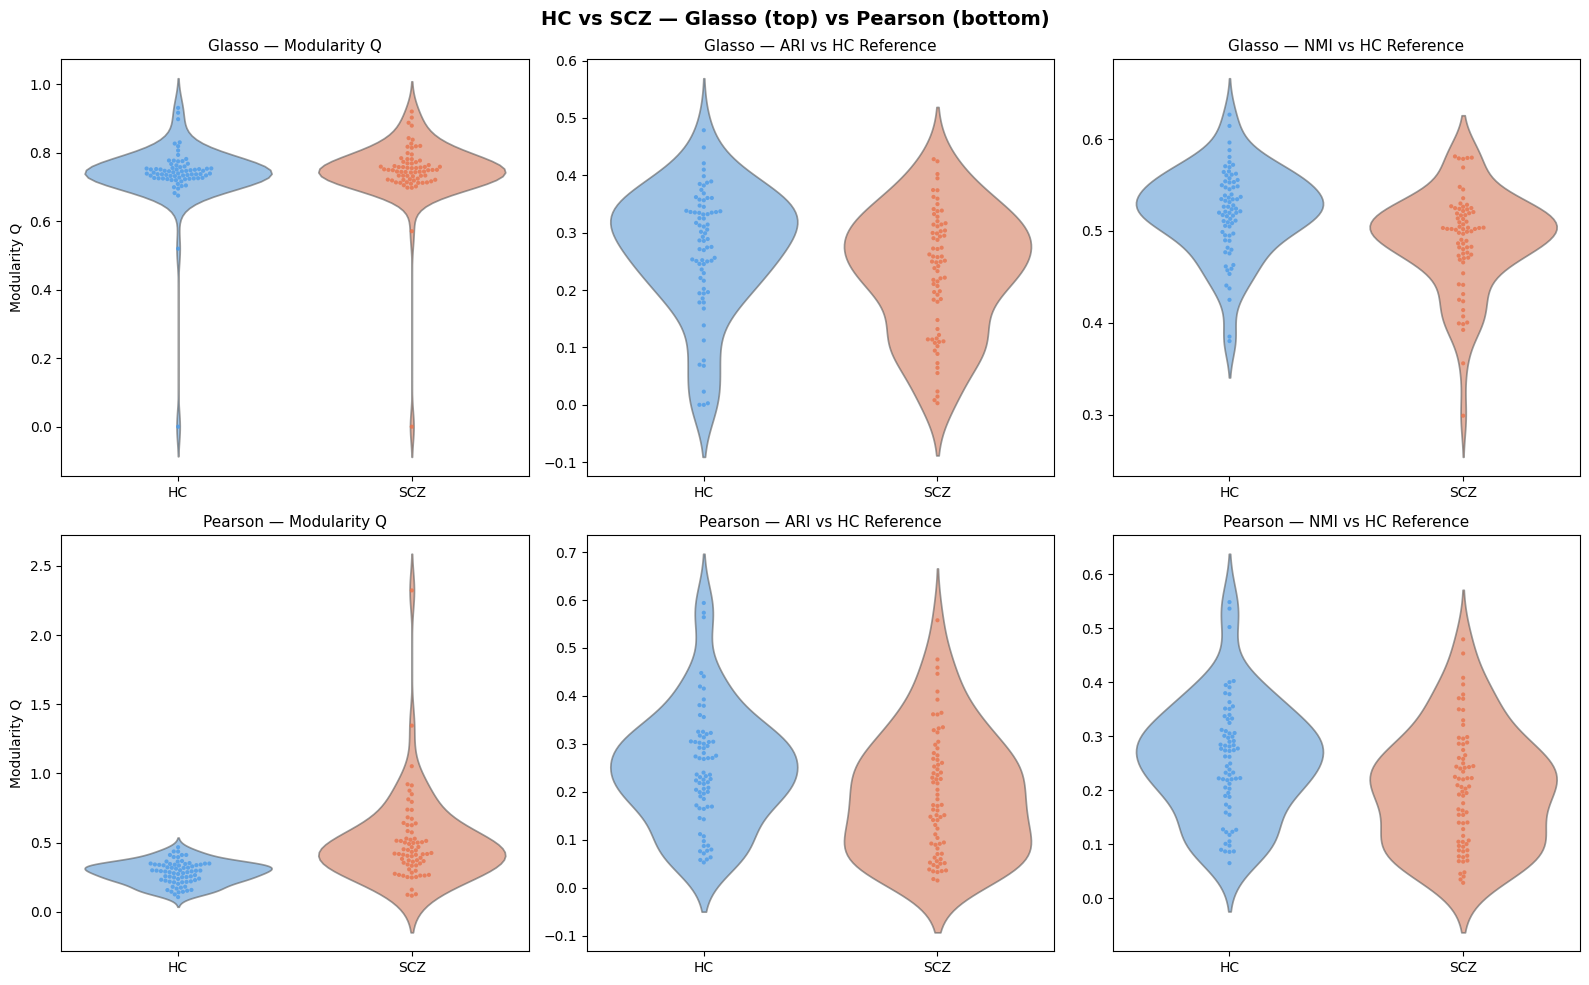

In [35]:
# ── VISUALISATION 1: Q, ARI, NMI distributions for both methods ───────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('HC vs SCZ — Glasso (top) vs Pearson (bottom)',
             fontsize=14, fontweight='bold')

metrics_info = [
    ('q',   'Modularity Q'),
    ('ari', 'ARI vs HC Reference'),
    ('nmi', 'NMI vs HC Reference')
]

for row_idx, (method_name, dfm) in enumerate([('Glasso', df_glasso),
                                               ('Pearson', df_pearson)]):
    for col_idx, (metric, ylabel) in enumerate(metrics_info):
        ax = axes[row_idx, col_idx]
        sns.violinplot(data=dfm, x='group', y=metric, palette=PALETTE,
                       order=['HC','SCZ'], inner=None, ax=ax, alpha=0.6)
        sns.swarmplot(data=dfm, x='group', y=metric, palette=PALETTE,
                      order=['HC','SCZ'], size=3, ax=ax, alpha=0.8)
        ax.set_title(f'{method_name} — {ylabel}', fontsize=11)
        ax.set_xlabel('')
        ax.set_ylabel(ylabel if col_idx == 0 else '')

plt.tight_layout()
plt.savefig('fig1_q_distribution_dual.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
# Diagnostic: confirm np.abs was actually applied AND check the suspect subject
print('=== Verifying matrices have no negative values ===')
print(f'HC  Pearson — any negative entries? {(matrices_hc_pearson < 0).any()}')
print(f'SCZ Pearson — any negative entries? {(matrices_scz_pearson < 0).any()}')
print(f'HC  Pearson value range: [{matrices_hc_pearson.min():.3f}, {matrices_hc_pearson.max():.3f}]')
print(f'SCZ Pearson value range: [{matrices_scz_pearson.min():.3f}, {matrices_scz_pearson.max():.3f}]')

print('\n=== Re-checking subjects with Q > 1.0 ===')
outlier_subjects = df_pearson[df_pearson.q > 1.0]
print(f'Subjects still with Q > 1.0: {len(outlier_subjects)}')
print(outlier_subjects[['subject_idx','group','q','n_communities']])

# For each surviving outlier, check the graph properties
for _, row in outlier_subjects.iterrows():
    idx, grp = int(row['subject_idx']), row['group']
    M = matrices_hc_pearson[idx] if grp == 'HC' else matrices_scz_pearson[idx]
    G = graphs_hc_pearson[idx]   if grp == 'HC' else graphs_scz_pearson[idx]
    
    print(f'\n{grp} subject {idx} (Q={row.q:.3f}):')
    print(f'  matrix range : [{M.min():.4f}, {M.max():.4f}]')
    print(f'  any negative : {(M < 0).any()}')
    print(f'  graph nodes  : {G.number_of_nodes()}')
    print(f'  graph edges  : {G.number_of_edges()}')
    
    # Edge weight stats from the actual graph
    edge_weights = [d['weight'] for _,_,d in G.edges(data=True)]
    print(f'  edge weight range: [{min(edge_weights):.4f}, {max(edge_weights):.4f}]')
    print(f'  total edge weight (2m): {sum(edge_weights)*2:.2f}')
    
    # Check connected component

=== Verifying matrices have no negative values ===
HC  Pearson — any negative entries? False
SCZ Pearson — any negative entries? True
HC  Pearson value range: [0.000, 0.937]
SCZ Pearson value range: [-0.784, 0.903]

=== Re-checking subjects with Q > 1.0 ===
Subjects still with Q > 1.0: 3
     subject_idx group         q  n_communities
77             4   SCZ  1.345899              5
126           53   SCZ  2.322906              5
134           61   SCZ  1.052620              6

SCZ subject 4 (Q=1.346):
  matrix range : [-0.6681, 0.7353]
  any negative : True
  graph nodes  : 1019
  graph edges  : 123809
  edge weight range: [-0.6681, 0.7353]
  total edge weight (2m): 32727.74

SCZ subject 53 (Q=2.323):
  matrix range : [-0.7400, 0.7868]
  any negative : True
  graph nodes  : 1019
  graph edges  : 161504
  edge weight range: [-0.7400, 0.7868]
  total edge weight (2m): 24371.17

SCZ subject 61 (Q=1.053):
  matrix range : [-0.7590, 0.8935]
  any negative : True
  graph nodes  : 1019
  grap

In [26]:
# Investigate Pearson outliers
outlier_subjects = df_pearson[df_pearson.q > 1.0].copy()
print(f'Subjects with Q > 1.0: {len(outlier_subjects)}')
print(outlier_subjects[['subject_idx','group','q','n_communities']].sort_values('q', ascending=False))

# For each outlier, check the underlying matrix for anomalies
for _, row in outlier_subjects.iterrows():
    idx, grp = row['subject_idx'], row['group']
    M = matrices_hc_pearson[idx] if grp == 'HC' else matrices_scz_pearson[idx]
    print(f'\n{grp} subject {idx} (Q={row.q:.3f}):')
    print(f'  matrix value range: [{M.min():.3f}, {M.max():.3f}]')
    print(f'  fraction of zero entries: {(M == 0).sum() / M.size:.3f}')
    print(f'  number of edges in graph: '
          f'{(np.abs(M) > 0).sum() // 2}')
    print(f'  number of negative edges: {(M < 0).sum() // 2}')

Subjects with Q > 1.0: 3
     subject_idx group         q  n_communities
126           53   SCZ  2.322906              5
77             4   SCZ  1.345899              5
134           61   SCZ  1.052620              6

SCZ subject 4 (Q=1.346):
  matrix value range: [-0.668, 0.735]
  fraction of zero entries: 0.762
  number of edges in graph: 123809
  number of negative edges: 43888

SCZ subject 53 (Q=2.323):
  matrix value range: [-0.740, 0.787]
  fraction of zero entries: 0.689
  number of edges in graph: 161504
  number of negative edges: 68525

SCZ subject 61 (Q=1.053):
  matrix value range: [-0.759, 0.894]
  fraction of zero entries: 0.760
  number of edges in graph: 124703
  number of negative edges: 36590


---
## Cell 9 — Identify Spurious Inter-Community Edges

This is the analytical core of the project.

**Definition of a spurious edge:**
An edge (i, j) is 'spurious' in a given SCZ subject if:
- ROI i and ROI j belong to **different communities in the HC reference partition**
- The edge weight |w(i,j)| in the SCZ subject is significantly higher than the HC group average |w(i,j)|

This operationalises the idea that two brain regions which are normally in separate networks
are 'talking too much' in schizophrenia, creating pathological bridges between networks.

**Why absolute value?**
Precision matrix entries can be negative (inhibitory connections). A strongly negative
inter-community edge is also anomalous — it represents an unexpected inhibitory coupling
across network boundaries. We therefore use |w| as the measure of connection strength.

**Algorithm:**
1. For every pair (i, j) with i < j (upper triangle only, to avoid double-counting),
   determine whether they are in the same or different HC reference communities.
2. Compute the HC mean and SD of |w(i,j)| across all HC subjects.
3. For each SCZ subject, compute the z-score of |w(i,j)| relative to the HC distribution.
4. A z-score > 2.0 flags the edge as 'spuriously strong' in that subject.
5. For each ROI, count how many spurious inter-community edges it participates in
   across all SCZ subjects — this is the **bridge score** of that node.

In [20]:
#SPURIOUS_Z_THRESHOLD = 2.0  # z-score cutoff; 2.0 ≈ p < 0.05 one-tailed
SPURIOUS_Z_THRESHOLD = 3.0
# ── Pre-compute HC mean and SD for every edge (i,j) ──────────────────────────
# Shape: (N_HC, N_ROI, N_ROI) → mean and std over axis 0
hc_mean_abs = np.abs(matrices_hc).mean(axis=0)  # (N_ROI, N_ROI)
hc_std_abs  = np.abs(matrices_hc).std(axis=0)   # (N_ROI, N_ROI)

# Avoid division by zero for edges with zero HC variance
hc_std_abs[hc_std_abs < 1e-10] = 1e-10

# ── Build a boolean mask: True where (i,j) cross HC community boundaries ──────
# We work with the UPPER TRIANGLE to avoid double-counting (i < j)
nodes = sorted(hc_reference_partition.keys())
n     = len(nodes)

# cross_community_mask[i, j] = True if nodes i and j are in different HC communities
cross_mask = np.zeros((n, n), dtype=bool)
for ii in range(n):
    for jj in range(ii+1, n):
        if hc_reference_partition[nodes[ii]] != hc_reference_partition[nodes[jj]]:
            cross_mask[ii, jj] = True

# ── For each SCZ subject, find their spurious edges ───────────────────────────
# bridge_counts[roi_index] = total number of spurious inter-community edges
#                             this ROI participates in, summed over all SCZ subjects
bridge_counts = np.zeros(n)

# Also store per-subject lists of (i, j, z_score) for the healing step
scz_spurious_edges = []  # one list of (i,j,z) per SCZ subject

for A_scz in matrices_scz:
    A_abs = np.abs(A_scz)
    # z-score relative to HC distribution, upper triangle only
    z_matrix = (A_abs - hc_mean_abs) / hc_std_abs

    # spurious = cross-community AND z > threshold AND upper triangle
    spurious_mask = cross_mask & (z_matrix > SPURIOUS_Z_THRESHOLD)

    # collect as sorted list of (i, j, z) for this subject
    ij_pairs = np.argwhere(spurious_mask)
    subj_edges = [(i, j, z_matrix[i, j]) for i, j in ij_pairs]
    subj_edges.sort(key=lambda x: -x[2])  # sort by z-score descending
    scz_spurious_edges.append(subj_edges)

    # accumulate bridge counts
    for i, j, _ in subj_edges:
        bridge_counts[i] += 1
        bridge_counts[j] += 1

# ── Summary ───────────────────────────────────────────────────────────────────
top10_idx   = np.argsort(bridge_counts)[::-1][:10]
top10_names = [all_labels[i] for i in top10_idx]
top10_counts = bridge_counts[top10_idx]

print('Top 10 bridge ROIs (spurious inter-community edges across all SCZ subjects):')
for name, count in zip(top10_names, top10_counts):
    print(f'  {name:<55s}  bridge_count = {int(count)}')

avg_spurious = np.mean([len(e) for e in scz_spurious_edges])
print(f'\nAverage number of spurious edges per SCZ subject: {avg_spurious:.1f}')

Top 10 bridge ROIs (spurious inter-community edges across all SCZ subjects):
  7Networks_RH_Cont_Temp_3                                 bridge_count = 543
  7Networks_RH_DorsAttn_Post_6                             bridge_count = 505
  7Networks_RH_DorsAttn_FEF_4                              bridge_count = 459
  7Networks_RH_DorsAttn_FEF_1                              bridge_count = 458
  7Networks_LH_Cont_Temp_3                                 bridge_count = 457
  7Networks_RH_Default_Temp_3                              bridge_count = 433
  7Networks_LH_DorsAttn_Post_6                             bridge_count = 431
  7Networks_RH_SomMot_75                                   bridge_count = 409
  7Networks_RH_Cont_PFCl_29                                bridge_count = 403
  7Networks_RH_DorsAttn_FEF_6                              bridge_count = 398

Average number of spurious edges per SCZ subject: 1448.8


---
## Cell 10 — VISUALISATION 2: Bridge Node Map on 3D Brain

We use `nilearn.plotting.plot_connectome` to render nodes on a glass brain.
- **Node size** encodes the bridge score (larger = more spurious inter-community connections)
- **Node colour** encodes the HC reference community membership
- **Edges** shown only for the top-k most spurious connections across all SCZ subjects

**Two panels:** left = HC reference (clean community structure), right = SCZ spurious bridges.

**Alternative:** `plot_stat_map` with a volume-level bridge score projected onto the atlas.
This gives a smoother visual but is harder to interpret community-by-community.

---
## Cell 11 — VISUALISATION 3: Bridge Node Bar Chart (Top 15 ROIs)

A horizontal bar chart where each bar = one brain region,
bar length = its total bridge count across all SCZ subjects.
Bars are coloured by the HC community the region belongs to,
so you can see whether bridge nodes come from specific networks.

In [22]:
TOP_N = 15
top_idx    = np.argsort(bridge_counts)[::-1][:TOP_N]
top_names  = [all_labels[i] for i in top_idx]
top_scores = bridge_counts[top_idx]
top_comm_colours = [
    comm_colour[hc_reference_partition[i]]
    for i in top_idx
]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    range(TOP_N), top_scores[::-1],
    color=top_comm_colours[::-1],
    edgecolor='white', linewidth=0.5
)
ax.set_yticks(range(TOP_N))
ax.set_yticklabels(top_names[::-1], fontsize=9)
ax.set_xlabel('Total spurious inter-community edge count (across all SCZ subjects)', fontsize=10)
ax.set_title(f'Top {TOP_N} Bridge ROIs in Schizophrenia\n'
             'Bar colour = HC reference community membership', fontsize=11)
ax.axvline(0, color='black', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig3_bridge_nodes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig3_bridge_nodes.png')

NameError: name 'comm_colour' is not defined

---
## Cell 12 — The Simulated Healing Experiment

For each SCZ subject we:
1. Sort their spurious edges by z-score (most pathological first)
2. Progressively zero out the top-k% of those edges
3. Re-run Louvain and record Q and ARI at each step
4. Plot Q and ARI as a function of % edges removed

**What we are testing:**
If the abnormal community structure is driven by a small number of critical bridges,
we expect Q and ARI to recover rapidly as we remove the first few percent of edges.
A gradual linear recovery would suggest the abnormality is diffuse.

**Important caveat:**
Removing edges from a precision matrix is a mathematical operation, not a biological one.
This is a *thought experiment* to understand which edges structurally cause the dysconnectivity,
not a model of treatment. The correct interpretation is:
'If these connections were normalised to HC baseline levels, how much would the
network organisation recover?'

**Computational note:**
We run this on a SUBSET of SCZ subjects (e.g., 10) to keep runtime manageable.
Each Louvain call per subject per removal step adds up quickly.
For a paper-quality analysis you would run all subjects overnight.

In [23]:
# ── Configuration ─────────────────────────────────────────────────────────────
# Removal steps: 0%, 5%, 10%, ..., 100% of spurious edges
REMOVAL_STEPS    = list(range(0, 101, 5))  # [0, 5, 10, ..., 100]
N_SUBJECTS_HEAL  = min(10, N_SCZ)          # run on first 10 SCZ subjects

healing_records = []  # will become a dataframe

print(f'Running healing simulation on {N_SUBJECTS_HEAL} SCZ subjects...')

for subj_idx in tqdm(range(N_SUBJECTS_HEAL), desc='SCZ subjects'):
    A_original    = matrices_scz[subj_idx].copy()
    spurious_edges = scz_spurious_edges[subj_idx]  # sorted by z-score descending

    n_spurious = len(spurious_edges)

    for pct in REMOVAL_STEPS:
        # Number of edges to zero out at this step
        n_remove = int(np.round(pct / 100 * n_spurious))

        A_healed = A_original.copy()

        # Zero out the top-n_remove spurious edges
        # Alternative: replace with HC mean value instead of 0
        # (hc_mean_abs[i,j] * sign of original edge)
        # That is arguably more biologically honest but introduces a new assumption.
        # We use zeroing here for simplicity and interpretability.
        for i, j, _ in spurious_edges[:n_remove]:
            A_healed[i, j] = 0.0
            A_healed[j, i] = 0.0

        G_healed = nx.from_numpy_array(A_healed)

        # Skip if graph becomes too sparse to run Louvain
        if G_healed.number_of_edges() == 0:
            continue

        partition_healed = louvain(
            G_healed, threshold=THRESHOLD, max_levels=MAX_LEVELS, gamma=GAMMA
        )
        q_healed = modularity(G_healed, partition_healed)

        # ARI between healed partition and HC reference
        common = sorted(set(partition_healed.keys()) & set(hc_reference_partition.keys()))
        ari_healed = adjusted_rand_score(
            [hc_reference_partition[nd] for nd in common],
            [partition_healed[nd]       for nd in common]
        )

        healing_records.append({
            'subject_idx' : subj_idx,
            'pct_removed' : pct,
            'n_removed'   : n_remove,
            'q'           : q_healed,
            'ari'         : ari_healed
        })

df_heal = pd.DataFrame(healing_records)
print(f'\nHealing records: {len(df_heal)} rows')
display(df_heal.groupby('pct_removed')[['q', 'ari']].mean().round(4))

Running healing simulation on 10 SCZ subjects...


SCZ subjects:   0%|          | 0/10 [00:00<?, ?it/s]

KeyboardInterrupt: 

---
## Cell 13 — VISUALISATION 4: Healing Curves (Q and ARI vs % Edges Removed)

Each thin line = one SCZ subject. The thick line = mean across subjects.
The HC group mean is shown as a horizontal dashed line — the 'target' the healing is aiming for.

**Reading the chart:**
- If the curves converge toward the HC line: removing those edges genuinely recovers healthy-like organisation
- If Q overshoots the HC line: we removed too many edges and the network became over-fragmented
- A steep recovery in the first 10-20% of removal = a small number of edges drives most of the pathology

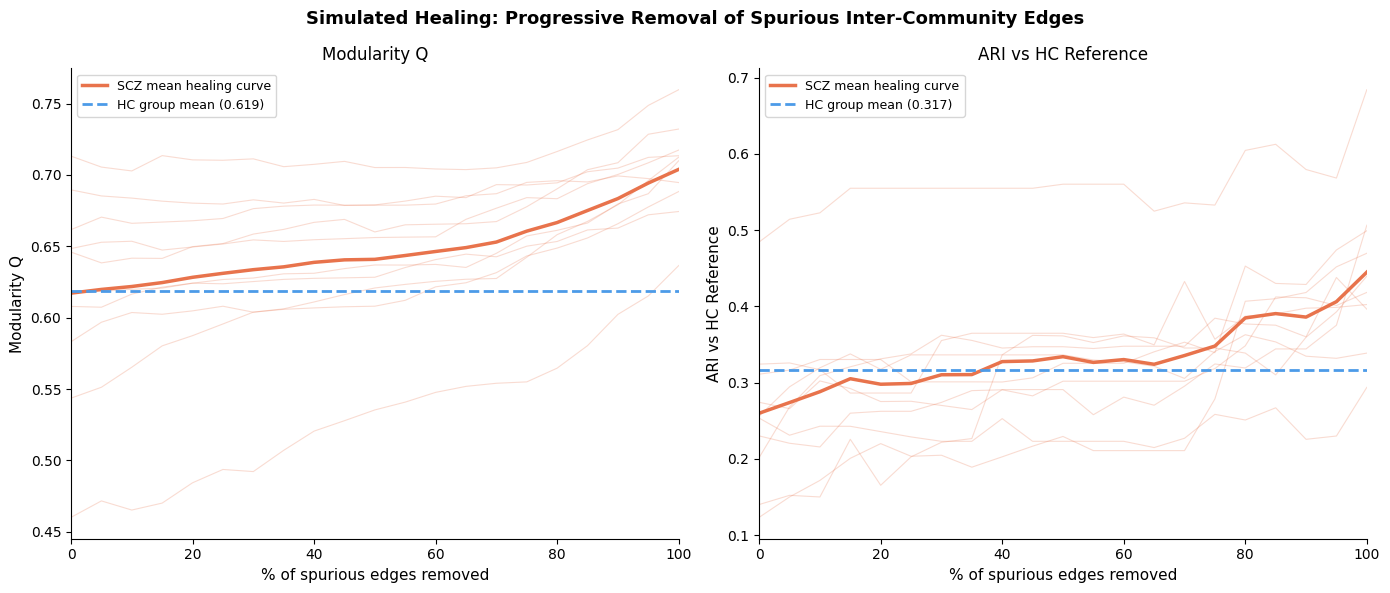

Figure saved: fig4_healing_curves.png


In [ ]:
hc_q_mean  = df[df.group == 'HC']['q'].mean()
hc_ari_mean = df[df.group == 'HC']['ari'].mean()  # HC vs HC-reference ARI baseline

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Simulated Healing: Progressive Removal of Spurious Inter-Community Edges',
             fontsize=13, fontweight='bold')

for metric, ax, hc_line, ylabel in [
    ('q',   axes[0], hc_q_mean,  'Modularity Q'),
    ('ari', axes[1], hc_ari_mean, 'ARI vs HC Reference')
]:
    # Individual subject lines
    for subj_idx in df_heal['subject_idx'].unique():
        subj_data = df_heal[df_heal.subject_idx == subj_idx].sort_values('pct_removed')
        ax.plot(
            subj_data['pct_removed'], subj_data[metric],
            color=PALETTE['SCZ'], alpha=0.25, linewidth=0.8
        )

    # Mean healing curve
    mean_curve = df_heal.groupby('pct_removed')[metric].mean()
    ax.plot(
        mean_curve.index, mean_curve.values,
        color=PALETTE['SCZ'], linewidth=2.5, label='SCZ mean healing curve'
    )

    # HC target line
    ax.axhline(hc_line, color=PALETTE['HC'], linestyle='--', linewidth=2.0,
               label=f'HC group mean ({hc_line:.3f})')

    ax.set_xlabel('% of spurious edges removed', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(ylabel, fontsize=12)
    ax.legend(fontsize=9)
    ax.set_xlim(0, 100)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig4_healing_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig4_healing_curves.png')

---
## Cell 14 — VISUALISATION 5: 3D Brain Map of Community Structure (nilearn glass brain)

A richer version of the brain visualisation from Cell 10, now using `plot_glass_brain`
to show a 3D-projected view with the actual community partition rendered as a stat map.

**Two maps:**
1. The HC reference partition projected as a label volume onto the Schaefer atlas image
2. The average bridge score per ROI projected onto the same volume

**Technical approach:**
We create a new NIfTI image where each parcel voxel's value = the community ID (map 1)
or bridge score (map 2), then plot with `plot_roi` or `plot_stat_map`.
This is the most neuroimaging-standard way to display parcellation-level results.

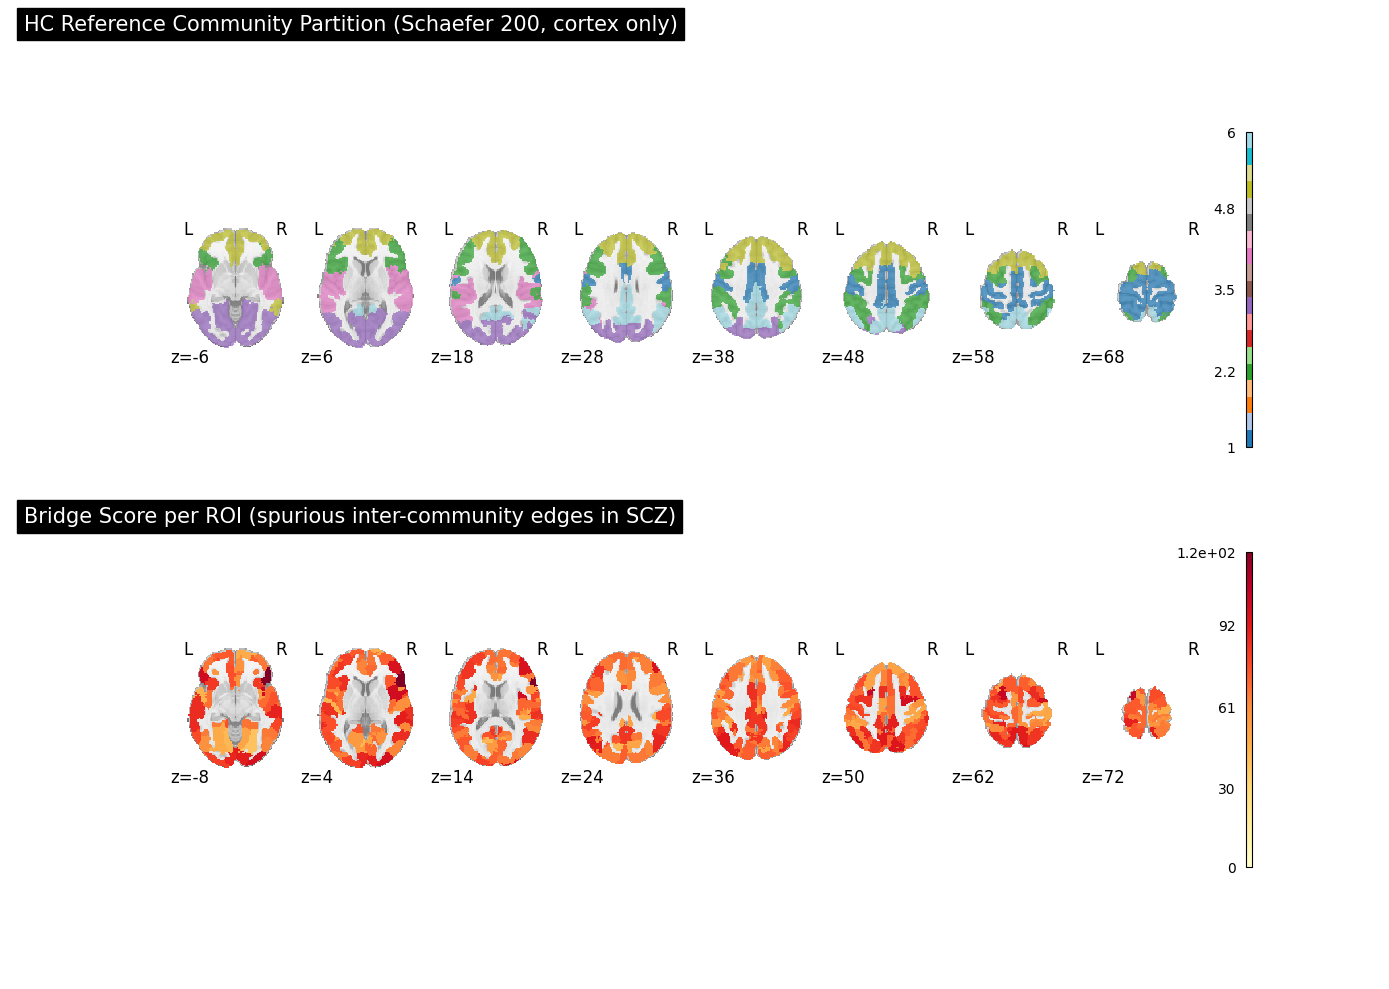

Figure saved: fig5_brain_stat_maps.png


In [ ]:
# ── Build community-label volume from Schaefer atlas ─────────────────────────
# We only do this for the 200 Schaefer cortical ROIs (the atlas image we have in memory)
# Subcortical ROIs are shown separately using HO atlas

schaefer_img   = nib.load(atlas_schaefer.maps)
schaefer_data  = schaefer_img.get_fdata().copy()

# Create empty target volumes
comm_vol   = np.zeros_like(schaefer_data)   # community ID map
bridge_vol = np.zeros_like(schaefer_data)   # bridge score map

for roi_idx in range(min(200, n)):  # Schaefer ROIs are indices 0..199
    label_id = roi_idx + 1          # Schaefer labels are 1-indexed in the image
    voxel_mask = (schaefer_data == label_id)

    # community ID from HC reference (remap to 1..K to avoid 0 = background confusion)
    comm_id = list(community_ids).index(hc_reference_partition[roi_idx]) + 1
    comm_vol[voxel_mask]   = comm_id
    bridge_vol[voxel_mask] = bridge_counts[roi_idx]

# Wrap as NIfTI images
comm_img   = image.new_img_like(schaefer_img, comm_vol)
bridge_img = image.new_img_like(schaefer_img, bridge_vol)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Community ID map — use a qualitative colormap
plotting.plot_roi(
    comm_img,
    title='HC Reference Community Partition (Schaefer 200, cortex only)',
    display_mode='z',
    cut_coords=8,
    cmap='tab20',
    axes=axes[0]
)

# Bridge score map — use a sequential colormap (hotter = more bridge activity)
plotting.plot_stat_map(
    bridge_img,
    title='Bridge Score per ROI (spurious inter-community edges in SCZ)',
    display_mode='z',
    cut_coords=8,
    cmap='YlOrRd',
    colorbar=True,
    axes=axes[1]
)

plt.tight_layout()
plt.savefig('fig5_brain_stat_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig5_brain_stat_maps.png')

---
## Cell 15 — Summary Table and Interpretation

Collect all key numbers into a single printable summary.

In [ ]:
hc_q  = df[df.group=='HC']['q']
scz_q = df[df.group=='SCZ']['q']
hc_ari  = df[df.group=='HC']['ari']
scz_ari = df[df.group=='SCZ']['ari']

_, p_q   = mannwhitneyu(hc_q,   scz_q,   alternative='two-sided')
_, p_ari = mannwhitneyu(hc_ari, scz_ari, alternative='two-sided')

# Healing: Q at 0% removal vs Q at 20% removal (first non-trivial milestone)
q_before = df_heal[df_heal.pct_removed == 0]['q'].mean()
q_after  = df_heal[df_heal.pct_removed == 20]['q'].mean() if 20 in df_heal.pct_removed.values else np.nan

print('=' * 65)
print('SUMMARY OF RESULTS')
print('=' * 65)
print(f'Subjects analysed:    HC = {N_HC}, SCZ = {N_SCZ}')
print(f'ROIs per subject:     {n}')
print(f'HC reference communities: {n_communities}')
print()
print(f'Mean Q  —  HC: {hc_q.mean():.4f} ± {hc_q.std():.4f}')
print(f'Mean Q  — SCZ: {scz_q.mean():.4f} ± {scz_q.std():.4f}  (p = {p_q:.4f})')
print()
print(f'Mean ARI vs HC reference  —  HC: {hc_ari.mean():.4f} ± {hc_ari.std():.4f}')
print(f'Mean ARI vs HC reference  — SCZ: {scz_ari.mean():.4f} ± {scz_ari.std():.4f}  (p = {p_ari:.4f})')
print()
print(f'Average spurious inter-community edges per SCZ subject: {avg_spurious:.1f}')
print(f'Top bridge ROI: {all_labels[top10_idx[0]]} (count = {int(top10_counts[0])})')
print()
print(f'Healing sim (first 10 SCZ subjects):')
print(f'  Q before healing:  {q_before:.4f}')
print(f'  Q after 20% edges removed: {q_after:.4f}')
print(f'  HC target Q: {hc_q.mean():.4f}')
print('=' * 65)

SUMMARY OF RESULTS
Subjects analysed:    HC = 15, SCZ = 14
ROIs per subject:     219
HC reference communities: 7

Mean Q  —  HC: 0.6188 ± 0.0413
Mean Q  — SCZ: 0.6250 ± 0.0743  (p = 0.5557)

Mean ARI vs HC reference  —  HC: 0.3166 ± 0.0527
Mean ARI vs HC reference  — SCZ: 0.2584 ± 0.0911  (p = 0.0174)

Average spurious inter-community edges per SCZ subject: 550.1
Top bridge ROI: Right Cerebral White Matter (count = 131)

Healing sim (first 10 SCZ subjects):
  Q before healing:  0.6172
  Q after 20% edges removed: 0.6283
  HC target Q: 0.6188


---
## Cell 16 — Optional Extensions and Known Limitations

### Limitations of this pipeline

1. **Louvain is non-deterministic** in its general form. Our implementation visits nodes in a fixed
   NetworkX-determined order, making it deterministic but potentially sensitive to that order.
   For robustness you should run Louvain k=10 times per subject with random node orderings
   and use the run with the highest Q (standard practice in the community detection literature).

2. **Resolution parameter γ = 1.0** finds communities at the 'natural' scale of the graph.
   Brain networks are known to be hierarchical — there are large-scale networks (DMN, visual)
   and smaller sub-networks within them. A multi-resolution analysis (varying γ from 0.5 to 2.0)
   would give a richer picture of at which scale the SCZ abnormality appears.

3. **Negative edges** in the precision matrix are handled by the modularity formula but
   their neurobiological meaning is debated. Some groups replace negative edges with 0
   before community detection to avoid artefacts.

4. **The 'healing' is asymmetric** — we only remove spuriously strong inter-community edges,
   not spuriously weak intra-community edges (the 'missing cohesion' problem).
   A complete healing model would do both.

5. **Age and sex confounds** — the COBRE dataset has age and sex differences between groups.
   Ideally you would regress these out from Q, ARI, and bridge scores before comparing groups.

### Natural extensions

- Run the analysis at multiple γ values and plot Q(γ) curves per group
- Use consensus clustering (Option B from Cell 5) for a more robust HC reference
- Replace zeroing with regression-to-HC-mean in the healing simulation
- Add FD (frame displacement) as a covariate to control for motion artefacts
- Apply the same pipeline to a replication dataset (e.g., ABIDE for autism) to test generalisability